<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW5_Q5</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 🧠 Multilayer Perceptron (MLP) Regression
### Manual Implementation with PyTorch Tensors

> **University:** University of Tehran
> **Course:** Machine Learning
> **Assignment:** Homework 5 - Question 5
> **Topic:** Deep Learning, Neural Networks, PyTorch Autograd

---

## 📝 Problem Statement
The goal is to design and train a **Feed-Forward Neural Network (Multilayer Perceptron)** to predict house prices based on various features (e.g., `LotArea`, `YearBuilt`, `Neighborhood`).

**Constraint:** High-level wrappers (like `sklearn.neural_network`) are prohibited. The network architecture, forward propagation, and training loop must be implemented manually using **PyTorch** tensors.

**Key Objectives:**
1.  **Data Preprocessing:** Handle missing values, perform **Target Encoding** for categorical variables, and **Normalize** numerical features.
2.  **Architecture Design:** Construct a neural network class (`nn.Module`) with multiple hidden layers and **ReLU** activation.
3.  **Manual Training Loop:** Implement the gradient descent optimization loop:
    * Forward Pass
    * Compute Loss (**MSE**)
    * Backward Pass (Backpropagation)
    * Update Weights (**Adam Optimizer**)
4.  **Evaluation:** Assess model performance on test data using **RMSE**, **MAE**, **MAPE**, and **RMSLE**.

---

### Imports

In [193]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt 
import tensorflow as tf
import category_encoders as ce
import numpy as np
import numpy as np

### Load the Data and Data Overview

In [194]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
train_data

,Unnamed: 0,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,135,136,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,174000
1,1452,1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,145000
2,762,763,60,FV,72.0,8640,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,Con,Normal,215200
3,932,933,20,RL,84.0,11670,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,320000
4,435,436,60,RL,43.0,10667,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,4,2009,ConLw,Normal,212000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,1095,1096,20,RL,78.0,9317,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,176432
1018,1130,1131,50,RL,65.0,7804,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal,135000
1019,1294,1295,20,RL,60.0,8172,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,115000
1020,860,861,50,RL,55.0,7642,Pave,NaN,Reg,Lvl,...,0,NaN,GdPrv,NaN,0,6,2007,WD,Normal,189950


In [195]:
print(train_data.shape)
print(test_data.shape)

(1022, 82)
(438, 82)


## Preprocessing

#### Missing values

In [196]:
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,BedroomAbvGr,0.000000
2,HalfBath,0.000000
3,FullBath,0.000000
4,BsmtHalfBath,0.000000
...,...,...
77,MasVnrType,57.729941
78,Fence,80.234834
79,Alley,93.542074
80,MiscFeature,96.086106


In [197]:
train_data.drop(columns = ['PoolQC' , 'MiscFeature' , 'Alley' , 'Fence' , 'MasVnrType'] , axis = 1, inplace = True)

missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,TotalBsmtSF,0.000000
2,SaleCondition,0.000000
3,HeatingQC,0.000000
4,CentralAir,0.000000
...,...,...
72,GarageType,5.283757
73,GarageCond,5.283757
74,GarageYrBlt,5.283757
75,LotFrontage,18.590998


In [198]:
mask = train_data[['Fireplaces', 'FireplaceQu']].copy()  
mask

,Fireplaces,FireplaceQu
0,1,Gd
1,0,NaN
2,0,NaN
3,1,Gd
4,1,TA
...,...,...
1017,1,Gd
1018,2,TA
1019,0,NaN
1020,1,Gd


In [199]:
mask.loc[mask['FireplaceQu'].isna(), 'FireplaceQu'] = 'Zero' 
mask

,Fireplaces,FireplaceQu
0,1,Gd
1,0,Zero
2,0,Zero
3,1,Gd
4,1,TA
...,...,...
1017,1,Gd
1018,2,TA
1019,0,Zero
1020,1,Gd


In [200]:
train_data['FireplaceQu'] = mask['FireplaceQu']
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,KitchenAbvGr,0.000000
2,BedroomAbvGr,0.000000
3,HalfBath,0.000000
4,FullBath,0.000000
...,...,...
72,GarageQual,5.283757
73,GarageCond,5.283757
74,GarageType,5.283757
75,GarageFinish,5.283757


In [201]:
mask = train_data[['GarageType','GarageYrBlt','GarageFinish','GarageCars','GarageArea','GarageQual','GarageCond']].copy()  
mask

,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond
0,Attchd,1970.0,Unf,2,530,TA,TA
1,Basment,2005.0,Fin,2,525,TA,TA
2,Attchd,2009.0,Unf,2,614,TA,TA
3,Attchd,2006.0,Fin,3,788,TA,TA
4,Attchd,1996.0,RFn,2,550,TA,TA
...,...,...,...,...,...,...,...
1017,Attchd,2006.0,RFn,2,440,TA,TA
1018,Detchd,1981.0,Unf,2,576,TA,TA
1019,Detchd,1957.0,Unf,2,572,TA,TA
1020,Detchd,1925.0,Unf,1,216,TA,TA


In [202]:
mask.loc[mask['GarageType'].isna(), 'GarageType'] = 'Zero' 
mask.loc[mask['GarageYrBlt'].isna(), 'GarageYrBlt'] = 0 
mask.loc[mask['GarageFinish'].isna(), 'GarageFinish'] = 'Zero' 
mask.loc[mask['GarageQual'].isna(), 'GarageQual'] = 'Zero' 
mask.loc[mask['GarageCond'].isna(), 'GarageCond'] = 'Zero' 
mask

,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond
0,Attchd,1970.0,Unf,2,530,TA,TA
1,Basment,2005.0,Fin,2,525,TA,TA
2,Attchd,2009.0,Unf,2,614,TA,TA
3,Attchd,2006.0,Fin,3,788,TA,TA
4,Attchd,1996.0,RFn,2,550,TA,TA
...,...,...,...,...,...,...,...
1017,Attchd,2006.0,RFn,2,440,TA,TA
1018,Detchd,1981.0,Unf,2,576,TA,TA
1019,Detchd,1957.0,Unf,2,572,TA,TA
1020,Detchd,1925.0,Unf,1,216,TA,TA


In [203]:
train_data[['GarageType','GarageYrBlt','GarageFinish','GarageCars','GarageArea','GarageQual','GarageCond']] = mask[['GarageType','GarageYrBlt','GarageFinish','GarageCars','GarageArea','GarageQual','GarageCond']]
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,Fireplaces,0.000000
2,Functional,0.000000
3,TotRmsAbvGrd,0.000000
4,KitchenQual,0.000000
...,...,...
72,BsmtExposure,2.544031
73,BsmtFinType1,2.544031
74,BsmtFinType2,2.544031
75,BsmtQual,2.544031


In [204]:
mask = train_data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']].copy()  

In [205]:
mask.loc[mask['BsmtQual'].isna(), 'BsmtQual'] = 'Zero' 
mask.loc[mask['BsmtCond'].isna(), 'BsmtCond'] = 'Zero'
mask.loc[mask['BsmtExposure'].isna(), 'BsmtExposure'] = 'Zero' 
mask.loc[mask['BsmtFinType1'].isna(), 'BsmtFinType1'] = 'Zero' 
mask.loc[mask['BsmtFinType2'].isna(), 'BsmtFinType2'] = 'Zero' 
mask

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,BsmtFullBath,BsmtHalfBath
0,TA,TA,No,Unf,0,Unf,0,1304,0,0
1,Gd,TA,Gd,GLQ,547,Unf,0,0,1,0
2,Gd,TA,Mn,GLQ,24,Unf,0,732,0,0
3,Ex,Gd,No,Unf,0,Unf,0,1905,0,0
4,Gd,TA,Av,GLQ,385,ALQ,344,70,1,0
...,...,...,...,...,...,...,...,...,...,...
1017,Gd,TA,No,GLQ,24,Unf,0,1290,0,0
1018,TA,TA,No,BLQ,622,Unf,0,500,1,0
1019,TA,TA,No,Rec,167,Unf,0,697,1,0
1020,TA,TA,No,Unf,0,Unf,0,912,0,0


In [206]:
train_data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']] = mask[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']]
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,Fireplaces,0.000000
2,Functional,0.000000
3,TotRmsAbvGrd,0.000000
4,KitchenQual,0.000000
...,...,...
72,Foundation,0.000000
73,SalePrice,0.000000
74,Electrical,0.097847
75,MasVnrArea,0.293542


In [207]:
train_data.loc[train_data['LotFrontage'].isna(), 'LotFrontage'] = train_data['LotFrontage'].median()

In [208]:
train_data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']] = mask[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']]
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.000000
1,Fireplaces,0.000000
2,Functional,0.000000
3,TotRmsAbvGrd,0.000000
4,KitchenQual,0.000000
...,...,...
72,RoofStyle,0.000000
73,Foundation,0.000000
74,SalePrice,0.000000
75,Electrical,0.097847


In [209]:
train_data.dropna(subset=['Electrical', 'MasVnrArea'], inplace=True)

In [210]:
train_data[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']] = mask[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','BsmtFullBath','BsmtHalfBath']]
missing_data = (train_data.isna().sum().sort_values() / len(train_data)) * 100
missing_df = pd.DataFrame({'Feature': missing_data.index, 'Missing Percentage': missing_data.values})
display(missing_df)

,Feature,Missing Percentage
0,Unnamed: 0,0.0
1,Functional,0.0
2,TotRmsAbvGrd,0.0
3,KitchenQual,0.0
4,KitchenAbvGr,0.0
...,...,...
72,RoofMatl,0.0
73,RoofStyle,0.0
74,YearRemodAdd,0.0
75,ExterCond,0.0


In [211]:
test_data.drop(columns = ['PoolQC' , 'MiscFeature' , 'Alley' , 'Fence' , 'MasVnrType'] , axis = 1, inplace = True)

values_to_replace = {
    'FireplaceQu': 'Zero',
    'BsmtQual': 'Zero',
    'BsmtCond': 'Zero',
    'BsmtExposure' : 'Zero' ,  
    'BsmtFinType1' : 'Zero' , 
    'BsmtFinType2' : 'Zero' , 
    'GarageType'   : 'Zero' ,
    'GarageYrBlt'  : 0 ,
    'GarageFinish' : 'Zero' ,
    'GarageQual'   : 'Zero' ,
    'GarageCond'   : 'Zero' ,
    'LotFrontage'  : train_data['LotFrontage'].median()
}
test_data.dropna(subset=['Electrical', 'MasVnrArea'], inplace=True)
test_data = test_data.fillna(value=values_to_replace)


In [212]:
exclude_column = 'SalePrice'  
numerical_features = train_data.dtypes[train_data.dtypes != 'object'].index.drop(exclude_column)


train_mean = train_data[numerical_features].mean()
train_std = train_data[numerical_features].std()

train_data[numerical_features] = (train_data[numerical_features] - train_mean) / train_std
train_data[numerical_features] = train_data[numerical_features].fillna(0)

test_data[numerical_features] = (test_data[numerical_features] - train_mean) / train_std
test_data[numerical_features] = test_data[numerical_features].fillna(0)

print(test_data.shape)
print(train_data.shape)


(433, 77)
(1018, 77)


### feature selection

Text(0.5, 1.0, 'Correlation Matrix')

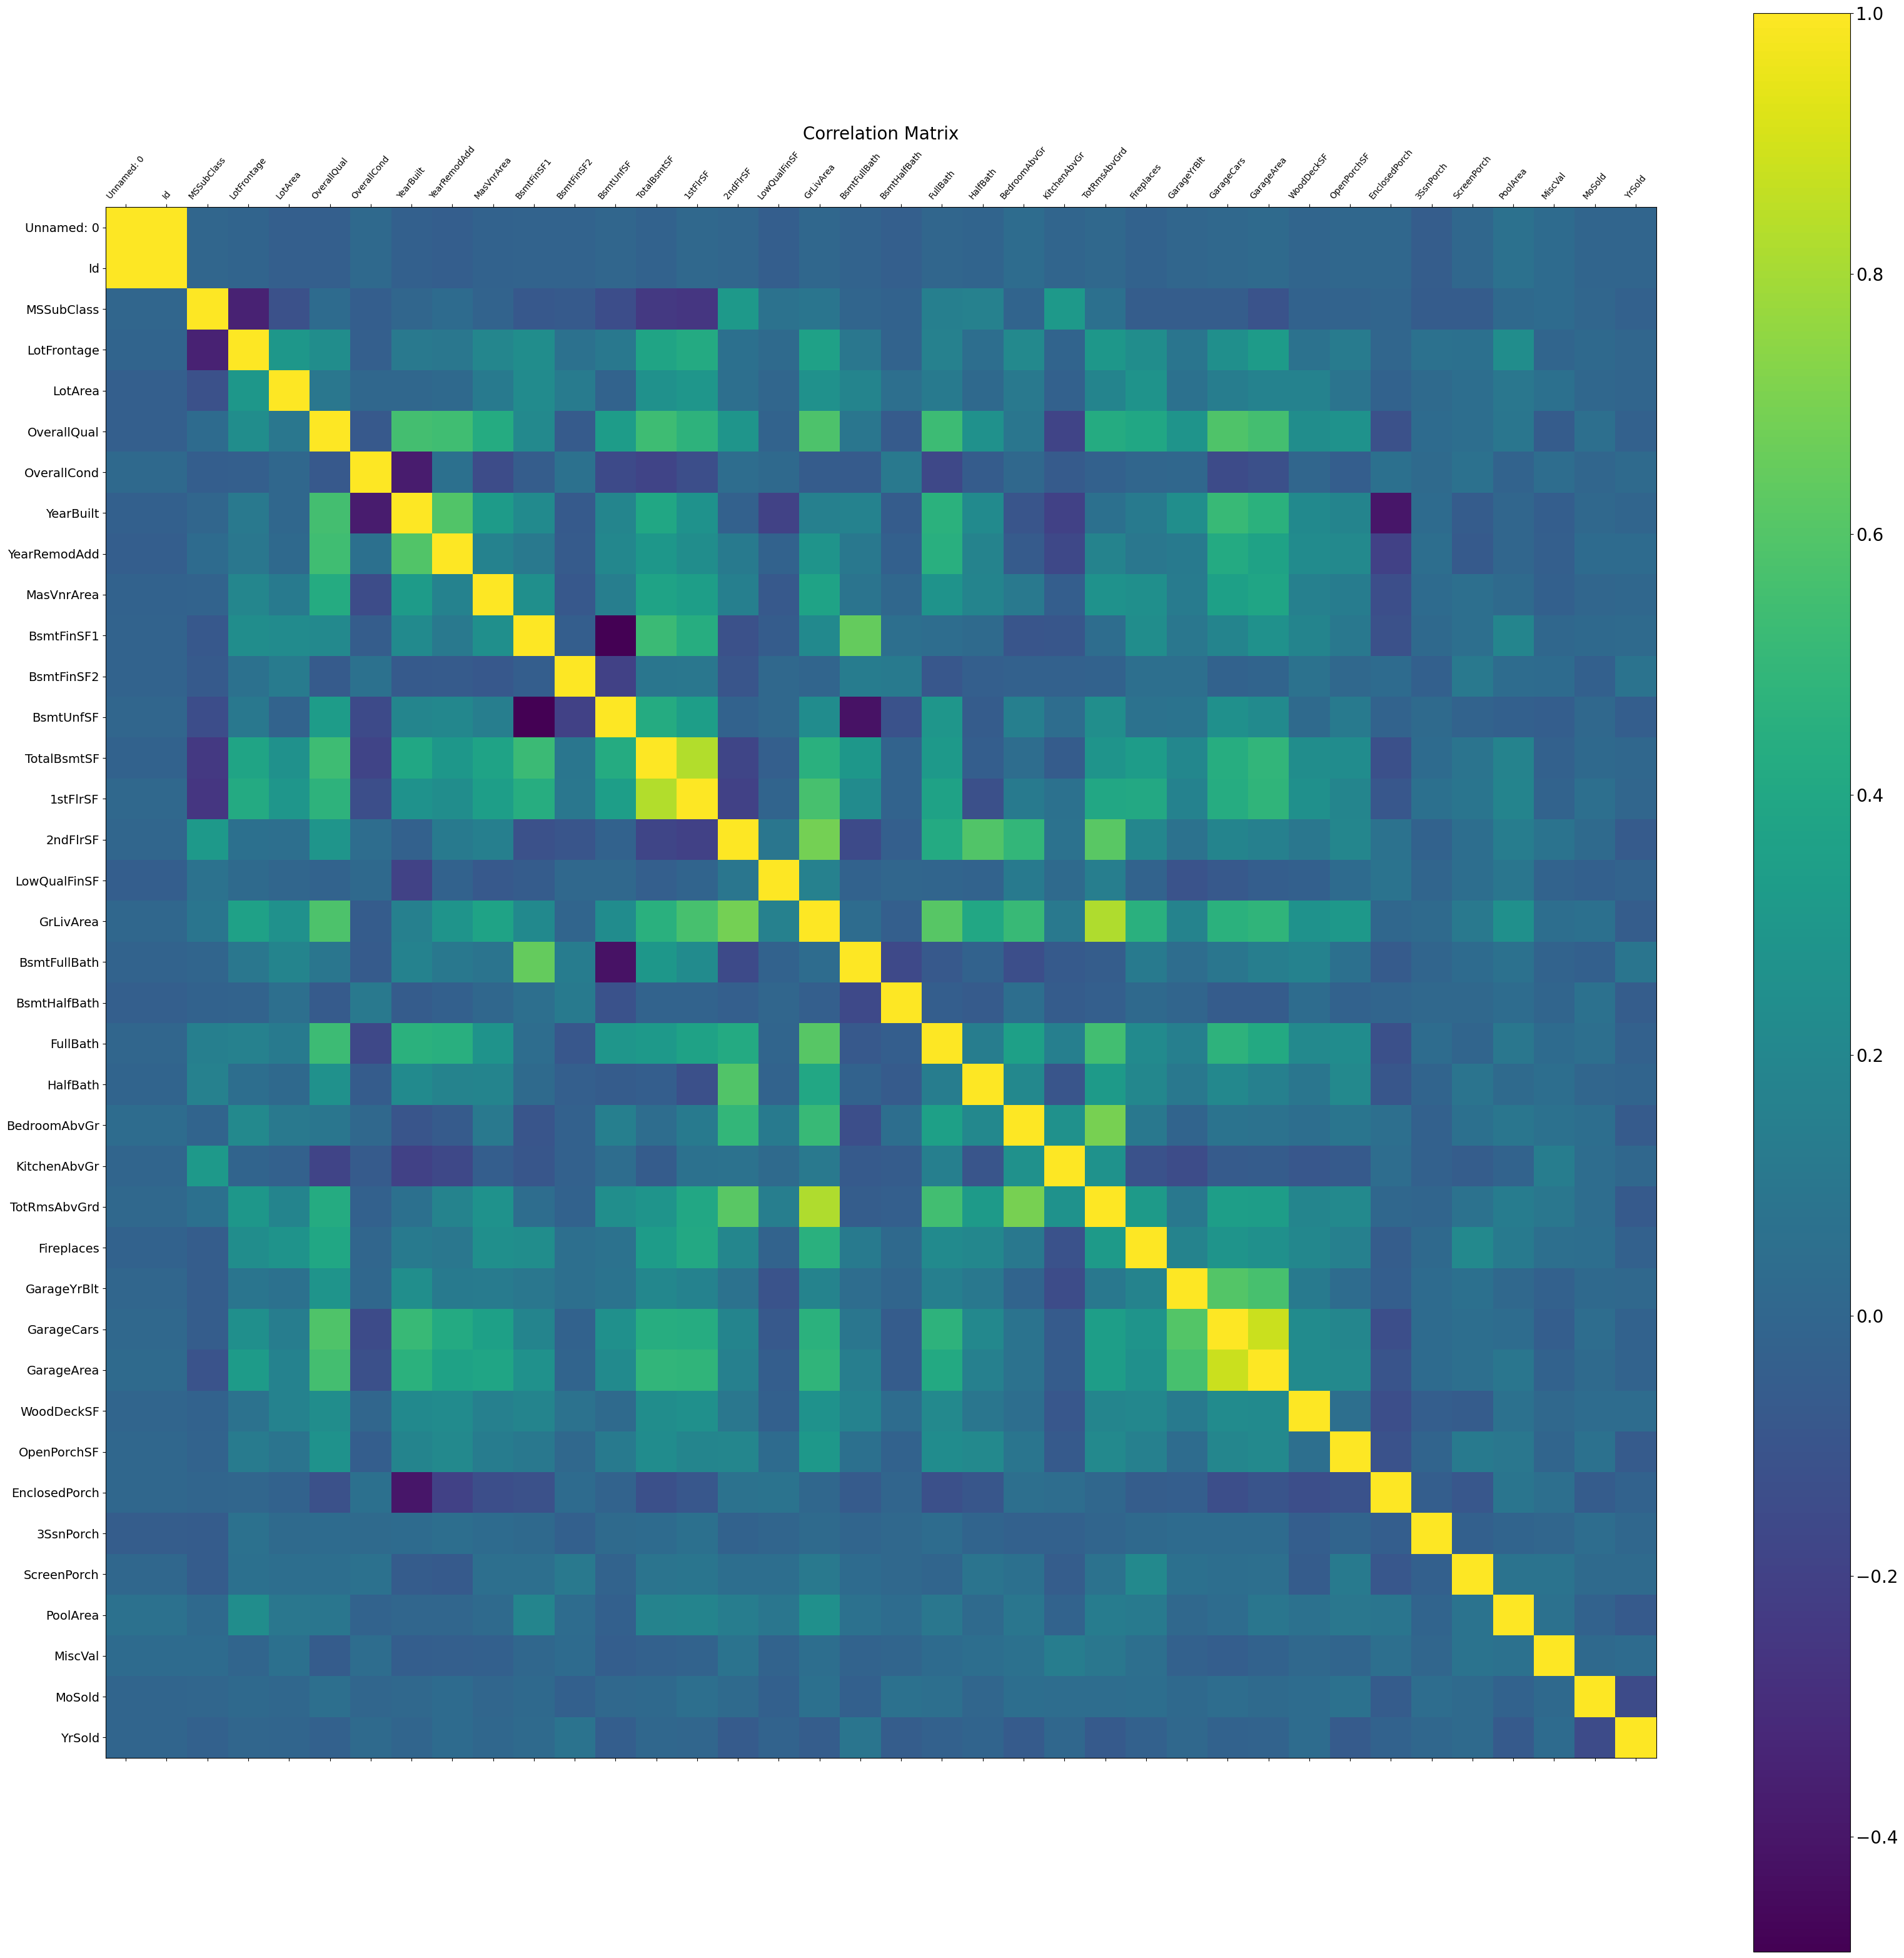

In [213]:
f = plt.figure(figsize=(40, 40))
plt.matshow(train_data[numerical_features].corr(), fignum=f.number)
plt.xticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=10, rotation=50)
plt.yticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize = 20)
plt.title('Correlation Matrix', fontsize=20)

In [214]:
train_data = train_data.drop(train_data.columns[0], axis=1)
train_data = train_data.drop(['Id'], axis=1)
train_data = train_data.drop(['MSSubClass'], axis=1)
train_data = train_data.drop(['OverallCond'], axis=1)
train_data = train_data.drop(['BsmtFinSF2'], axis=1)
train_data = train_data.drop(['LowQualFinSF'], axis=1)
train_data = train_data.drop(['BsmtHalfBath'], axis=1)
train_data = train_data.drop(['KitchenAbvGr'], axis=1)
train_data = train_data.drop(['EnclosedPorch'], axis=1)
train_data = train_data.drop(['YrSold'], axis=1)
train_data = train_data.drop(['MoSold'], axis=1)
train_data = train_data.drop(['MiscVal'], axis=1)
train_data = train_data.drop(['3SsnPorch'], axis=1)
train_data = train_data.drop(['ScreenPorch'], axis=1)
train_data = train_data.drop(['PoolArea'], axis=1)

test_data = test_data.drop(train_data.columns[0], axis=1)
test_data = test_data.drop(['Id'], axis=1)
test_data = test_data.drop(['MSSubClass'], axis=1)
test_data = test_data.drop(['OverallCond'], axis=1)
test_data = test_data.drop(['BsmtFinSF2'], axis=1)
test_data = test_data.drop(['LowQualFinSF'], axis=1)
test_data = test_data.drop(['BsmtHalfBath'], axis=1)
test_data = test_data.drop(['KitchenAbvGr'], axis=1)
test_data = test_data.drop(['EnclosedPorch'], axis=1)
test_data = test_data.drop(['YrSold'], axis=1)
test_data = test_data.drop(['MoSold'], axis=1)
test_data = test_data.drop(['MiscVal'], axis=1)
test_data = test_data.drop(['3SsnPorch'], axis=1)
test_data = test_data.drop(['ScreenPorch'], axis=1)
test_data = test_data.drop(['PoolArea'], axis=1)

Text(0.5, 1.0, 'Correlation Matrix')

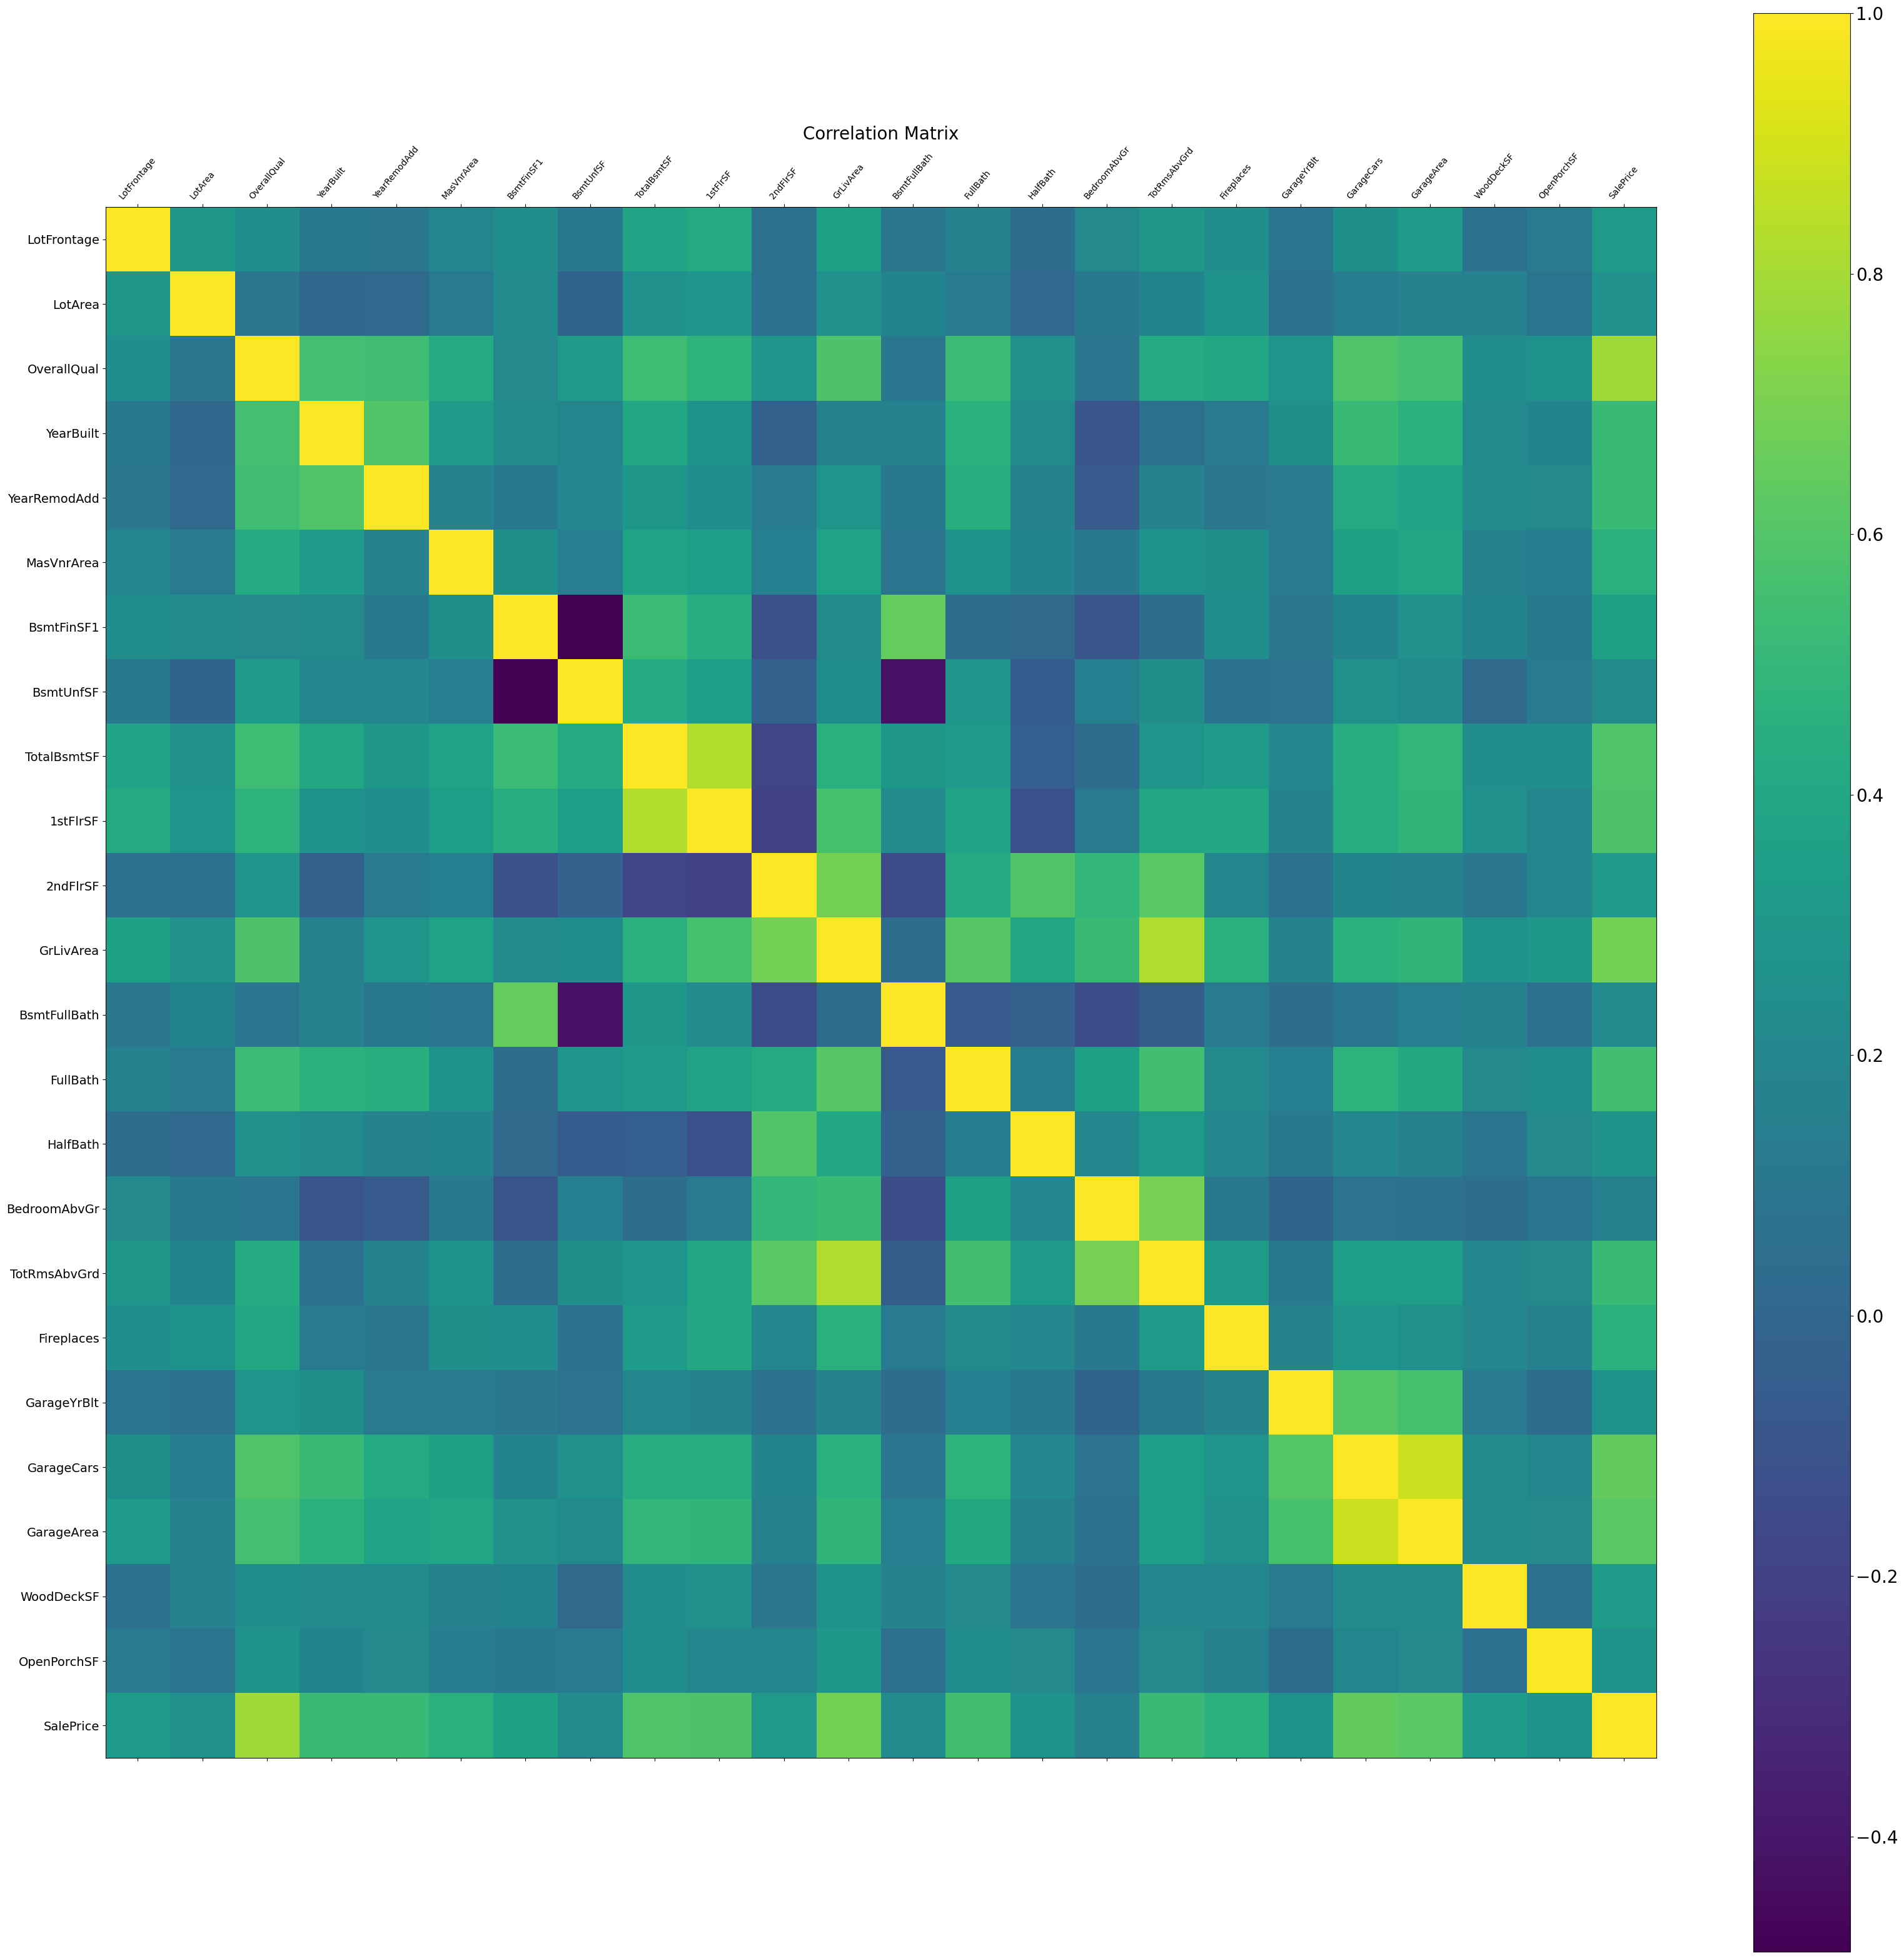

In [215]:
numerical_features = train_data.dtypes[train_data.dtypes != 'object'].index
f = plt.figure(figsize=(40, 40))
plt.matshow(train_data[numerical_features].corr(), fignum=f.number)
plt.xticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=10, rotation=50)
plt.yticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize = 20)
plt.title('Correlation Matrix', fontsize=20)

In [216]:
train_data = train_data.drop(['GarageCars'], axis=1)
train_data = train_data.drop(['TotRmsAbvGrd'], axis=1)
train_data = train_data.drop(['BsmtFullBath'], axis=1)
train_data = train_data.drop(['TotalBsmtSF'], axis=1)
train_data = train_data.drop(['2ndFlrSF'], axis=1)
train_data = train_data.drop(['FullBath'], axis=1)
train_data = train_data.drop(['1stFlrSF'], axis=1)
train_data = train_data.drop(['YearBuilt'], axis=1)
train_data = train_data.drop(['YearRemodAdd'], axis=1)
train_data = train_data.drop(['GarageYrBlt'], axis=1)
train_data = train_data.drop(['BedroomAbvGr'], axis=1)
train_data = train_data.drop(['HalfBath'], axis=1)

test_data = test_data.drop(['GarageCars'], axis=1)
test_data = test_data.drop(['TotRmsAbvGrd'], axis=1)
test_data = test_data.drop(['BsmtFullBath'], axis=1)
test_data = test_data.drop(['TotalBsmtSF'], axis=1)
test_data = test_data.drop(['2ndFlrSF'], axis=1)
test_data = test_data.drop(['FullBath'], axis=1)
test_data = test_data.drop(['1stFlrSF'], axis=1)
test_data = test_data.drop(['YearBuilt'], axis=1)
test_data = test_data.drop(['YearRemodAdd'], axis=1)
test_data = test_data.drop(['GarageYrBlt'], axis=1)
test_data = test_data.drop(['BedroomAbvGr'], axis=1)
test_data = test_data.drop(['HalfBath'], axis=1)

Text(0.5, 1.0, 'Correlation Matrix')

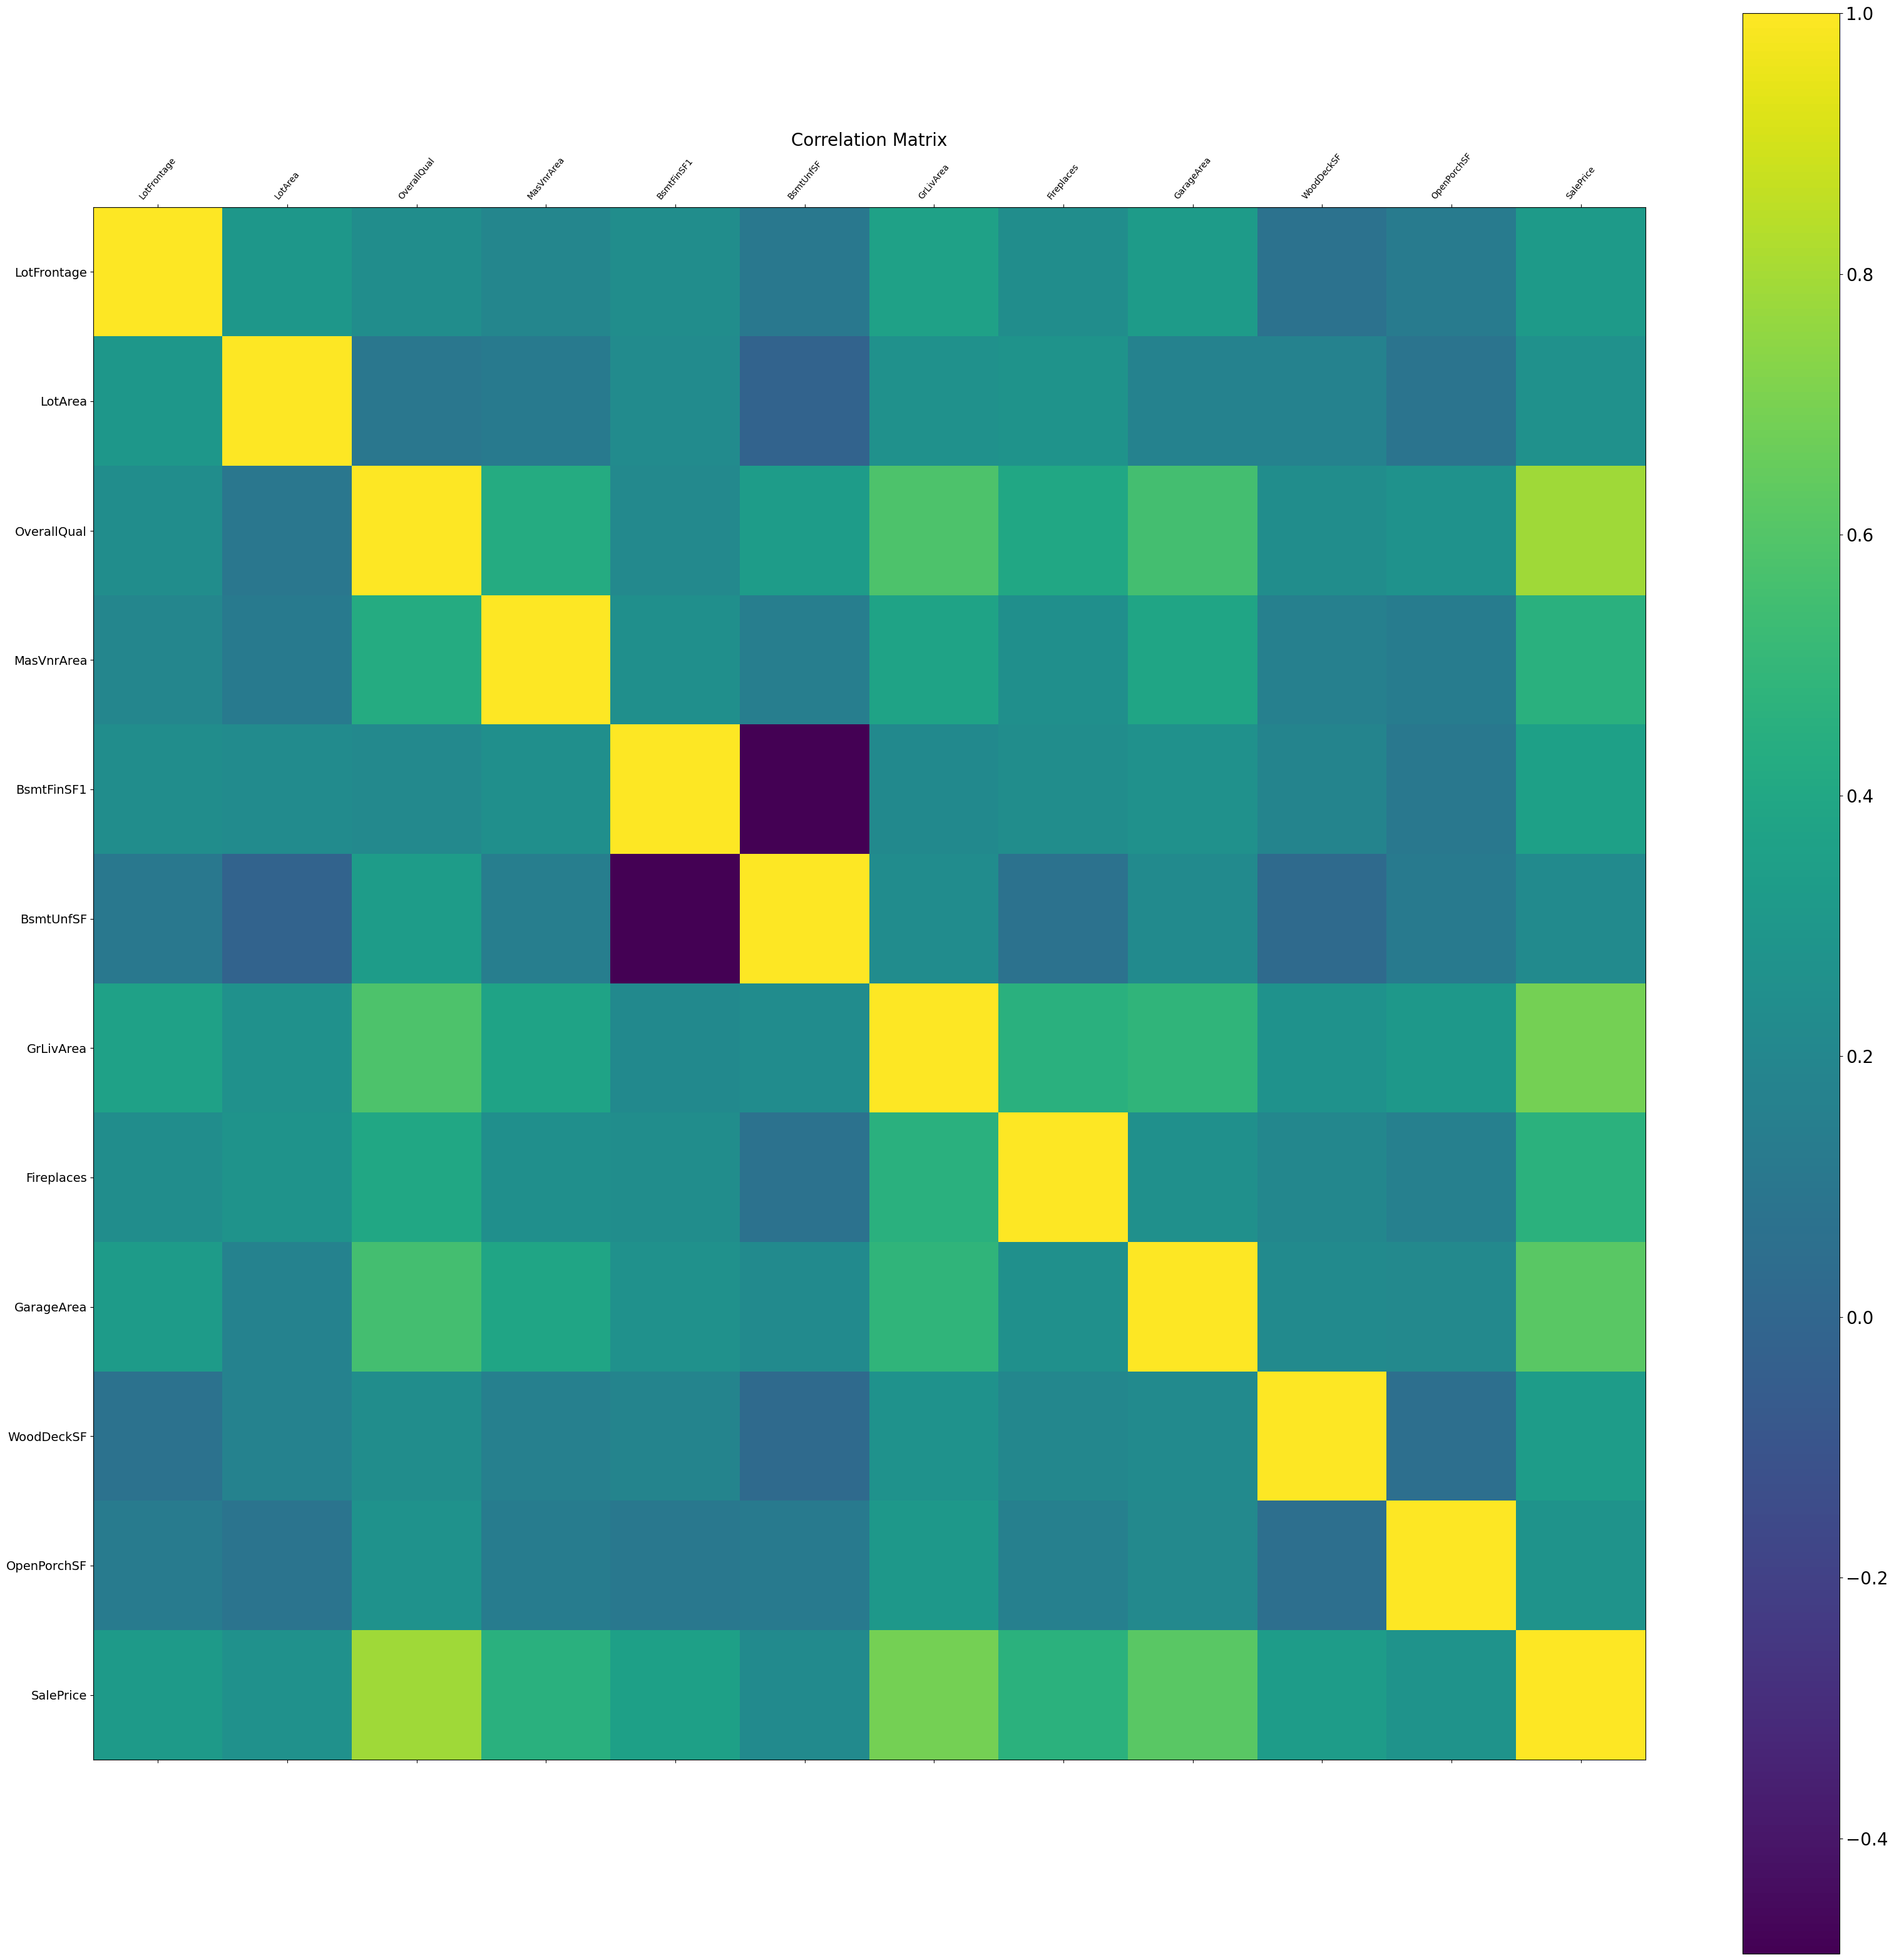

In [217]:
numerical_features = train_data.dtypes[train_data.dtypes != 'object'].index
f = plt.figure(figsize=(40, 40))
plt.matshow(train_data[numerical_features].corr(), fignum=f.number)
plt.xticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=10, rotation=50)
plt.yticks(range(train_data[numerical_features].select_dtypes(['number']).shape[1]), train_data[numerical_features].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize = 20)
plt.title('Correlation Matrix', fontsize=20)

In [218]:
test_data

,Unnamed: 0,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,SalePrice
0,0.379748,-0.014445,-0.206426,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,...,RFn,-1.020365,TA,TA,Y,0.716911,-0.714127,WD,Normal,154500
1,0.880321,1.200089,0.132084,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,...,RFn,1.125309,TA,TA,Y,0.671368,-0.251082,WD,Normal,325000
2,-0.745954,-0.621711,-0.158319,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,...,Unf,-0.560578,TA,TA,Y,-0.740457,-0.714127,WD,Normal,115000
3,-0.489792,-0.881968,-0.507227,Pave,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,...,Unf,-0.273210,TA,TA,Y,-0.740457,-0.366843,WD,Normal,159000
4,0.718164,0.809703,0.188650,Pave,IR1,HLS,AllPub,Inside,Gtl,Timber,...,Fin,2.083200,TA,TA,Y,0.990167,-0.714127,WD,Normal,315500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,0.269293,-0.014445,0.518966,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Sawyer,...,Fin,0.641575,TA,TA,Y,-0.740457,-0.714127,WD,Normal,171000
433,-0.938663,-0.014445,-0.227396,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,RFn,-0.809629,TA,TA,Y,-0.740457,-0.714127,WD,Normal,139000
434,-0.957464,-0.925344,-0.434978,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,...,Unf,-1.231101,Fa,TA,Y,0.337388,0.703949,WD,Normal,126175
436,-0.684851,-0.144573,0.140719,Pave,Reg,Lvl,AllPub,Corner,Gtl,Edwards,...,Unf,0.244050,TA,TA,Y,-0.740457,-0.048499,ConLI,Normal,110000


In [219]:
train_data

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,SalePrice
0,RL,0.419317,-0.031444,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,Unf,0.253629,TA,TA,Y,0.003408,-0.714127,WD,Normal,174000
1,RM,-1.532611,-0.623970,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,...,Fin,0.229682,TA,TA,Y,-0.740457,-0.308962,WD,Normal,145000
2,FV,0.072308,-0.186514,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,Unf,0.655943,TA,TA,Y,0.542330,-0.062969,Con,Normal,215200
3,RL,0.592822,0.080453,Pave,IR1,Lvl,AllPub,Corner,Gtl,Somerst,...,Fin,1.489308,TA,TA,Y,-0.740457,2.049675,WD,Normal,320000
4,RL,-1.185601,-0.007919,Pave,IR2,Lvl,AllPub,CulDSac,Gtl,CollgCr,...,RFn,0.349418,TA,TA,Y,0.458835,0.168553,ConLw,Normal,212000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,RL,0.332565,-0.126865,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,RFn,-0.177421,TA,TA,Y,-0.740457,-0.395783,WD,Normal,176432
1018,RL,-0.231325,-0.260172,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,...,Unf,0.473944,TA,TA,Y,2.531030,-0.077440,WD,Normal,135000
1019,RL,-0.448206,-0.227748,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,...,Unf,0.454786,TA,TA,N,-0.740457,-0.714127,WD,Normal,115000
1020,RL,-0.665087,-0.274446,Pave,Reg,Lvl,AllPub,Corner,Gtl,Crawfor,...,Unf,-1.250258,TA,TA,Y,-0.740457,2.758713,WD,Normal,189950


In [220]:

combined_data = pd.concat([train_data, test_data])

categorical_columns = combined_data.select_dtypes(include=['object']).columns

target_encoder = ce.TargetEncoder()

combined_data[categorical_columns] = target_encoder.fit_transform(combined_data[categorical_columns], combined_data['SalePrice'])

train_data_encoded = combined_data.loc[train_data.index]
test_data_encoded = combined_data.loc[test_data.index]

test_data_encoded = test_data_encoded.iloc[:, :-1]
train_data_encoded = train_data_encoded.iloc[:, :-1]

In [221]:
train_data_encoded

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,SalePrice
0,191120.150498,0.419317,-0.031444,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,189008.218389,...,142156.423140,0.253629,187204.148233,187606.006834,186147.371150,0.003408,-0.714127,173265.386994,175088.356245,174000
0,179226.096998,-0.014445,-0.206426,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,136990.211135,...,202020.547847,-1.020365,187204.148233,187606.006834,186147.371150,0.716911,-0.714127,173265.386994,175088.356245,154500
1,127280.866680,-1.532611,-0.623970,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,128237.273823,...,239964.400576,0.229682,187204.148233,187606.006834,186147.371150,-0.740457,-0.308962,173265.386994,175088.356245,145000
1,179226.096998,1.200089,0.132084,180833.514879,206125.896266,179847.556068,180653.842759,181621.988550,179636.506191,318421.179178,...,202020.547847,1.125309,187204.148233,187606.006834,186147.371150,0.671368,-0.251082,173265.386994,175088.356245,325000
2,211952.821760,0.072308,-0.186514,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,226359.581985,...,142156.423140,0.655943,187204.148233,187606.006834,186147.371150,0.542330,-0.062969,193245.427881,175088.356245,215200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,191120.150498,0.332565,-0.126865,180833.514879,206125.896266,179847.556068,180653.842759,176518.733014,179636.506191,197703.755992,...,202020.547847,-0.177421,187204.148233,187606.006834,186147.371150,-0.740457,-0.395783,173265.386994,175088.356245,176432
1018,191120.150498,-0.231325,-0.260172,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,156950.266850,...,142156.423140,0.473944,187204.148233,187606.006834,186147.371150,2.531030,-0.077440,173265.386994,175088.356245,135000
1019,191120.150498,-0.448206,-0.227748,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,128237.273823,...,142156.423140,0.454786,187204.148233,187606.006834,115098.873496,-0.740457,-0.714127,173265.386994,175088.356245,115000
1020,191120.150498,-0.665087,-0.274446,180833.514879,164204.092593,179847.556068,180653.842759,181621.988550,179636.506191,209392.448372,...,142156.423140,-1.250258,187204.148233,187606.006834,186147.371150,-0.740457,2.758713,173265.386994,175088.356245,189950


In [222]:
test_data_encoded

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,SaleType,SaleCondition,SalePrice
0,191120.150498,0.419317,-0.031444,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,189008.218389,...,142156.423140,0.253629,187204.148233,187606.006834,186147.37115,0.003408,-0.714127,173265.386994,175088.356245,174000
0,179226.096998,-0.014445,-0.206426,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,136990.211135,...,202020.547847,-1.020365,187204.148233,187606.006834,186147.37115,0.716911,-0.714127,173265.386994,175088.356245,154500
1,127280.866680,-1.532611,-0.623970,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,128237.273823,...,239964.400576,0.229682,187204.148233,187606.006834,186147.37115,-0.740457,-0.308962,173265.386994,175088.356245,145000
1,179226.096998,1.200089,0.132084,180833.514879,206125.896266,179847.556068,180653.842759,181621.988550,179636.506191,318421.179178,...,202020.547847,1.125309,187204.148233,187606.006834,186147.37115,0.671368,-0.251082,173265.386994,175088.356245,325000
2,211952.821760,0.072308,-0.186514,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,226359.581985,...,142156.423140,0.655943,187204.148233,187606.006834,186147.37115,0.542330,-0.062969,193245.427881,175088.356245,215200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,179226.096998,-0.925344,-0.434978,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,128230.090967,...,142156.423140,-1.231101,126843.741271,187606.006834,186147.37115,0.337388,0.703949,173265.386994,175088.356245,126175
436,191120.150498,-0.231325,-0.231890,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,192515.357547,...,239964.400576,-0.641998,187204.148233,187606.006834,186147.37115,-0.740457,-0.193201,173265.386994,175088.356245,174000
436,179226.096998,-0.144573,0.140719,180833.514879,164204.092593,179847.556068,180653.842759,181621.988550,179636.506191,128237.273823,...,142156.423140,0.244050,187204.148233,187606.006834,186147.37115,-0.740457,-0.048499,184229.906295,175088.356245,110000
437,191120.150498,-0.448206,-0.077877,180833.514879,164204.092593,179847.556068,180653.842759,176518.733014,179636.506191,126054.808930,...,142156.423140,0.473944,187204.148233,187606.006834,186147.37115,-0.740457,3.453281,173265.386994,175088.356245,129000


In [223]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for layer_size in hidden_layers:
            layers.append(nn.Linear(prev_size, layer_size))
            layers.append(nn.ReLU())
            prev_size = layer_size
        
        layers.append(nn.Linear(prev_size, output_size))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

X_train = train_data_encoded.iloc[:, :-1].values
y_train = train_data_encoded.iloc[:, -1].values.reshape(-1, 1)

X_test = test_data_encoded.iloc[:, :-1].values
y_test = test_data_encoded.iloc[:, -1].values.reshape(-1, 1)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

input_size = X_train.shape[1]
hidden_layers = [64, 64, 64]
output_size = 1

model = MLP(input_size, hidden_layers, output_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def root_mean_squared_error(predictions, targets):
    return torch.sqrt(torch.mean((predictions - targets) ** 2))

def mean_absolute_percentage_error(predictions, targets):
    return torch.mean(torch.abs((targets - predictions) / targets)) * 100

def root_mean_squared_log_error(predictions, targets):
    return torch.sqrt(torch.mean((torch.log1p(predictions) - torch.log1p(targets)) ** 2))

epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        predictions = outputs
        mse = criterion(predictions, y_train).item()
        mae = torch.mean(torch.abs(predictions - y_train)).item()
        mape = mean_absolute_percentage_error(predictions, y_train).item()
        rmse = root_mean_squared_error(predictions, y_train).item()
        rmsle = root_mean_squared_log_error(predictions, y_train).item()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4f}%, RMSE: {rmse:.4f}, RMSLE: {rmsle:.4f}')

model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_mse = criterion(test_outputs, y_test).item()
    test_mae = torch.mean(torch.abs(test_outputs - y_test)).item()
    test_mape = mean_absolute_percentage_error(test_outputs, y_test).item()
    test_rmse = root_mean_squared_error(test_outputs, y_test).item()
    test_rmsle = root_mean_squared_log_error(test_outputs, y_test).item()
    print(f'Test MSE: {test_mse:.4f}, Test MAE: {test_mae:.4f}, Test MAPE: {test_mape:.4f}%, Test RMSE: {test_rmse:.4f}, Test RMSLE: {test_rmsle:.4f}')


Epoch 100/1000, Loss: 2005199104.0000, MSE: 2005199104.0000, MAE: 29810.1016, MAPE: 17.3909%, RMSE: 44779.4492, RMSLE: 0.2234
Epoch 200/1000, Loss: 1642101376.0000, MSE: 1642101376.0000, MAE: 27175.7871, MAPE: 16.3198%, RMSE: 40522.8516, RMSLE: 0.2080
Epoch 300/1000, Loss: 1524135296.0000, MSE: 1524135296.0000, MAE: 26050.6719, MAPE: 15.1112%, RMSE: 39040.1758, RMSLE: 0.1988
Epoch 400/1000, Loss: 1474437120.0000, MSE: 1474437120.0000, MAE: 25735.6855, MAPE: 15.1395%, RMSE: 38398.3984, RMSLE: 0.1976
Epoch 500/1000, Loss: 1425936512.0000, MSE: 1425936512.0000, MAE: 25577.3906, MAPE: 15.1212%, RMSE: 37761.5742, RMSLE: 0.1965
Epoch 600/1000, Loss: 1409651712.0000, MSE: 1409651712.0000, MAE: 25532.5996, MAPE: 15.1553%, RMSE: 37545.3281, RMSLE: 0.1965
Epoch 700/1000, Loss: 1416903296.0000, MSE: 1416903296.0000, MAE: 26323.4609, MAPE: 16.0643%, RMSE: 37641.7773, RMSLE: 0.2016
Epoch 800/1000, Loss: 1353333504.0000, MSE: 1353333504.0000, MAE: 25683.4805, MAPE: 15.6745%, RMSE: 36787.6797, RMSLE: